## 02. Plot pair trajectories
**20 March 2025 by MiniUFO**

---
[TOC]

---
### 1. Introduction
With a `pairs` dataset extracted from a drifter dataset, we can do some statistics based on the these pairs and plot their initial positions of deployment.  But we also need to plot the full trajectories of selected pairs.  Here we are going to do this.

---

### 2. Calculation
#### 2.1 load the GLAD dataset and get original pairs

In [1]:
import numpy as np
import xarray as xr
import sys
sys.path.append('../../../')
from xdispersion import RelativeDispersion

drifters = xr.open_dataset('../../../data/glad32.nc')

rd = RelativeDispersion(drifters, maxtlen=4*24*85, ragged=True, ID='traj',
                        xpos='longitude', uvel='ve', time='time', Rearth=6371.2,
                        ypos='latitude' , vvel='vn', coord='latlon')

pairs = rd.get_all_pairs()

# filter original pairs from all pairs
condition = np.logical_and(pairs.r0>=0.08, pairs.r0<=0.18)
origin_pairs = pairs.where(condition, drop=True).astype(pairs.dtypes)
origin_pairs

there are 43518 pairs of particles


<xarray.Dataset> Size: 10kB
Dimensions:   (pair: 171, particle: 2)
Coordinates:
  * pair      (pair) int32 684B 5716 6266 6539 7083 ... 43389 43396 43425 43463
  * particle  (particle) int32 8B 0 1
Data variables:
    tlen      (pair) int32 684B 3557 3142 3759 1999 3661 ... 1314 4296 8039 3514
    stim      (pair) datetime64[ns] 1kB 2012-07-22T12:45:00 ... 2012-07-22T16...
    r0        (pair) float32 684B 0.08872 0.18 0.09602 ... 0.09732 0.08311
    pID       (pair, particle) int32 1kB 20 21 22 23 23 ... 281 282 283 285 286
    xpos0     (pair, particle) float32 1kB -88.2 -88.2 -88.2 ... -88.09 -88.08
    ypos0     (pair, particle) float32 1kB 28.8 28.8 28.8 ... 27.89 28.84 28.84
    idxI      (pair, particle) int32 1kB 121691 125248 ... 1556133 1559647
    idxJ      (pair, particle) int32 1kB 130550 134107 ... 1559647 1563161

#### 2.2 Get positional variables
To plot the full trajectories of any pairs, one need to load the positional variables into memory.  Note that loading the full data requires **padding with nans** so that the returned variables are not memory efficient.  With selected original pairs, this is not a serious problem.

In [2]:
lons = rd.load_variable(origin_pairs, 'longitude')
lats = rd.load_variable(origin_pairs, 'latitude')
lons

<xarray.DataArray (pair: 171, particle: 2, rtime: 8160)> Size: 11MB
array([[[-88.1956  , -88.19457 , -88.19354 , ...,        nan,
                nan,        nan],
        [-88.19522 , -88.19419 , -88.19316 , ...,        nan,
                nan,        nan]],

       [[-88.19959 , -88.19861 , -88.19762 , ...,        nan,
                nan,        nan],
        [-88.20097 , -88.19991 , -88.19887 , ...,        nan,
                nan,        nan]],

       [[-88.20097 , -88.19991 , -88.19887 , ...,        nan,
                nan,        nan],
        [-88.200386, -88.199394, -88.19841 , ...,        nan,
                nan,        nan]],

       ...,

       [[-89.166214, -89.16636 , -89.16659 , ...,        nan,
                nan,        nan],
        [-89.16498 , -89.16493 , -89.16503 , ...,        nan,
                nan,        nan]],

       [[-89.04132 , -89.04524 , -89.04906 , ...,        nan,
                nan,        nan],
        [-89.0412  , -89.04514 , -89.04895 , ...,        nan,
                nan,        nan]],

       [[-88.08504 , -88.084946, -88.08488 , ...,        nan,
                nan,        nan],
        [-88.08461 , -88.08459 , -88.08457 , ...,        nan,
                nan,        nan]]], shape=(171, 2, 8160), dtype=float32)
Coordinates:
  * pair      (pair) int32 684B 5716 6266 6539 7083 ... 43389 43396 43425 43463
  * particle  (particle) int64 16B 0 1
  * rtime     (rtime) float64 65kB 0.0 0.01042 0.02083 ... 84.97 84.98 84.99

The returned variable is of `['pair', 'particle', 'rtime']` size.  In order to make it continuous in memory, nans are padded.  Hence the subsequence calculation can make use of `xarray`'s functionality.

#### 2.3 Plotting the trajectories of selected pairs

In [3]:
# select positions of a single pair
lons_sel = lons.isel(pair=20)
lats_sel = lats.isel(pair=20)

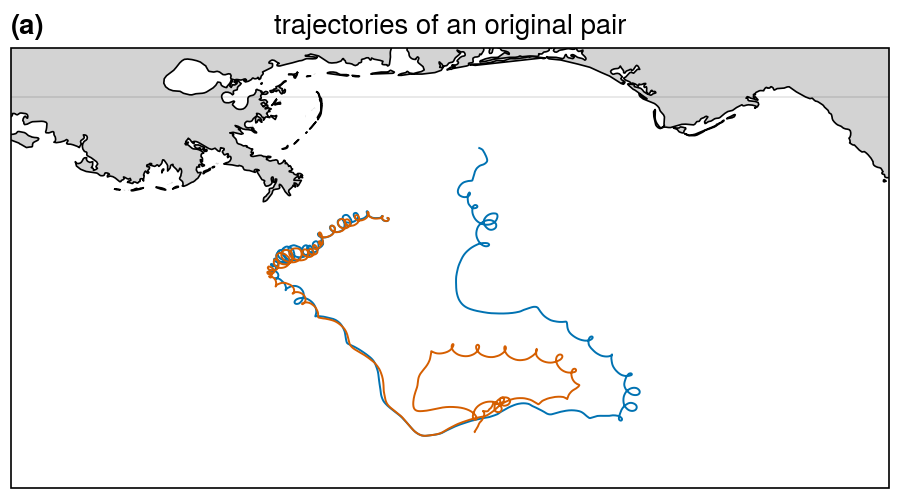

In [4]:
import ultraplot as uplt

fig, ax = uplt.subplots(figsize=(4.5,2.5), proj='cyl')
fig.set_facecolor('w')
ax.plot(lons_sel.T, lats_sel.T, lw=0.7) # n
ax.set_xlim([-92, -83])
ax.set_ylim([26, 30.5])
ax.set_title('trajectories of an original pair')
ax.format(abc='(a)', land=True, coast=True, reso='hi', landcolor='lightgray')

Now we could select 6 pairs and plot their trajectories

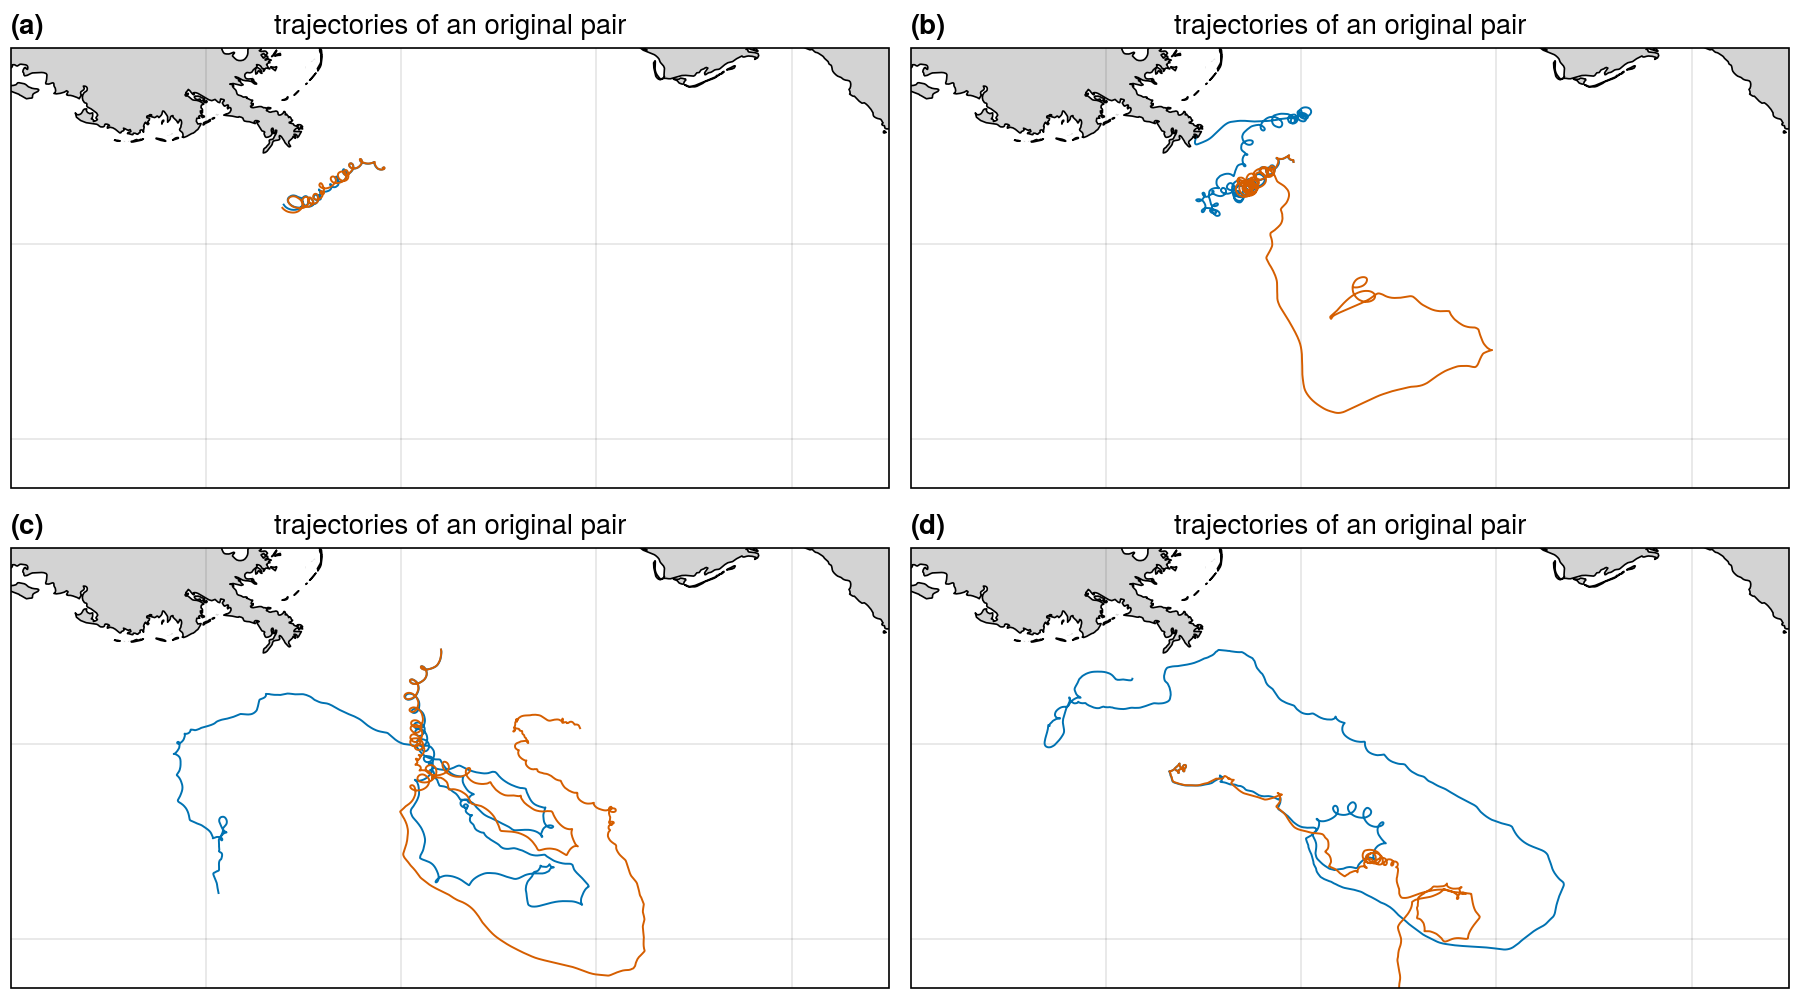

In [5]:
import ultraplot as uplt

pairIDs = [10, 50, 100, 120]

fig, axes = uplt.subplots(nrows=2, ncols=2, figsize=(9,5), proj='cyl')
fig.set_facecolor('w')
for i, ID in enumerate(pairIDs):
    lons_sel = lons.isel(pair=ID)
    lats_sel = lats.isel(pair=ID)
    ax = axes[i]
    ax.plot(lons_sel.T, lats_sel.T, lw=0.7) # n
    ax.set_xlim([-92, -83])
    ax.set_ylim([25.5, 30])
    ax.set_title('trajectories of an original pair')

axes.format(abc='(a)', land=True, coast=True, reso='hi', landcolor='lightgray', lonlines=2, latlines=2)

### 3. Conclusions

The loading of full data into memory is necessary for plotting the trajectories.  But it is less memory efficient as there could be a lot of nans in the returned variables.  For original pairs which are less than 200, this is not a problem.